<h1 style="text-align: center;"> Image Classification using Transfer Learning & CNN </h1>

<h3>Two Class Classification of Skin_Cancer Dataset </h3>


A. Use a pretrained VGG-16 model on Imagenet dataset by removing the top fully connected layers and adding three dense layers having 64, 32 and 2 neurons with relu, sigmoid and softmax activation functions respectively for classifying the two class Skin_Cancer RGB dataset given in Teams.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os
import glob as gb
import cv2
import PIL
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping ,ReduceLROnPlateau 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , Dense , Dropout , Flatten , MaxPooling2D , BatchNormalization
from tensorflow.keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from tensorflow import keras
from keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
pip install matplotlib==3.3.4


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 8.5/8.5 MB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
pwd

'C:\\Users\\sagej\\OneDrive\\Desktop\\STUDY MATERIAL\\Computer_vision_lab\\Skin_cancer_classification'

In [6]:
trainpath = 'C:\\Users\\sagej\\OneDrive\\Desktop\\STUDY MATERIAL\\Computer_vision_lab\\Skin_cancer_classification\\Skin_Cancer\\train'
testpath = 'C:\\Users\\sagej\\OneDrive\\Desktop\\STUDY MATERIAL\\Computer_vision_lab\\Skin_cancer_classification\\Skin_Cancer\\test'

In [4]:
new_size=224
train_images=[]
train_labels=[]
for i in os.listdir(trainpath):
  print("Entering to the folder name:",i)
  files=gb.glob(pathname=str(trainpath+'/' + i + '/*.jpg'))
  print("Number of images in the folder is",len(files))
  for j in files:
      class_cancer={'benign':0,'malignant':1}
      image_raw=cv2.imread(j)
      image=cv2.cvtColor(image_raw,cv2.COLOR_BGR2RGB)
      resize_image=cv2.resize(image,(new_size,new_size))
      train_images.append(list(resize_image))
      train_labels.append(class_cancer[i])

Entering to the folder name: benign
Number of images in the folder is 25
Entering to the folder name: malignant
Number of images in the folder is 25


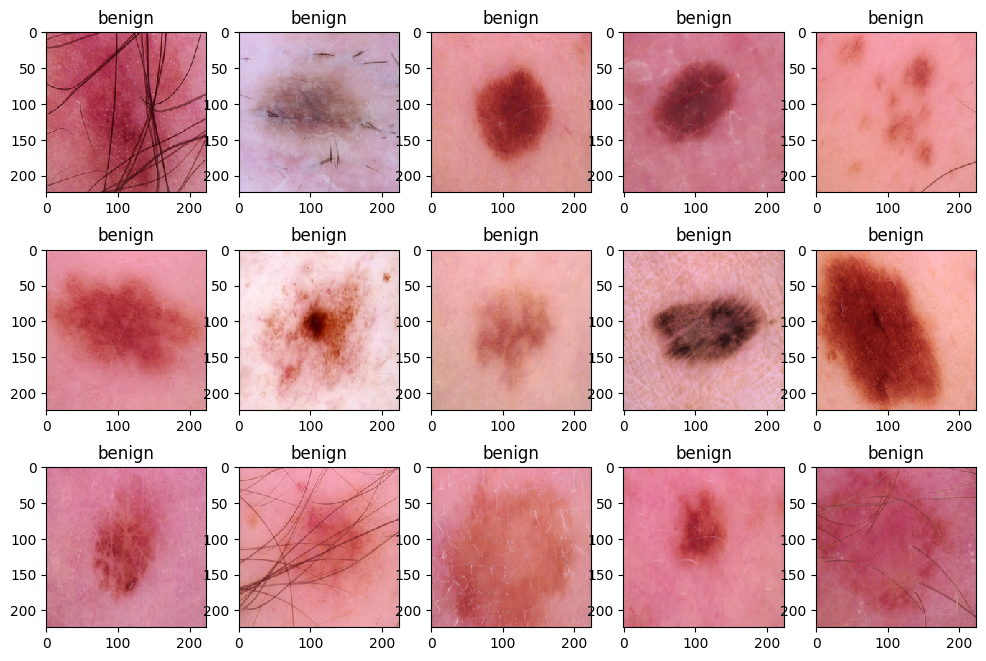

In [5]:
w=40
h=30
fig=plt.figure(figsize=(12, 8))
columns = 5
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if train_labels[i] == 0:
        ax.title.set_text('benign')
    elif train_labels[i] == 1:
        ax.title.set_text('malignant')
    plt.imshow(train_images[i], interpolation='nearest')
plt.show()

In [6]:
new_size=224
test_images=[]
test_labels=[]
for i in os.listdir(testpath):
  print("Entering to the folder name:",i)
  files=gb.glob(pathname=str(testpath +'/' + i + '/*.jpg'))
  print("Number of images in the folder is",len(files))
  class_cancer={'benign':0,'malignant':1}
  for j in files:
      image_raw=cv2.imread(j)
      image=cv2.cvtColor(image_raw,cv2.COLOR_BGR2RGB)
      resize_image=cv2.resize(image,(new_size,new_size))
      test_images.append(list(resize_image))
      test_labels.append(class_cancer[i])

Entering to the folder name: benign
Number of images in the folder is 25
Entering to the folder name: malignant
Number of images in the folder is 25


In [7]:
def list_to_array_train(train_images,train_labels):
  return np.array(train_images),np.array(train_labels)

X_train,y_train=list_to_array_train(train_images,train_labels)


def list_to_array_test(test_images,test_labels):
  return np.array(test_images),np.array(test_labels)


X_test,y_test=list_to_array_test(test_images,test_labels)

In [9]:
print(X_train.shape)
print("*"*20)
print(y_train.shape)
print("*"*20)
print(X_test.shape)
print(y_test.shape)

(50, 224, 224, 3)
********************
(50,)
********************
(50, 224, 224, 3)
(50,)


In [8]:
def keras_to_categorical(y_train,y_test):
  return to_categorical(y_train),to_categorical(y_test)

y_train,y_test=keras_to_categorical(y_train,y_test)
y_train.shape,y_test.shape

((50, 2), (50, 2))

In [9]:
def model_vgg16():
  VGG_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224, 3))
  
  for layer in VGG_model.layers:
    layer.trainable = False 
  feature=keras.layers.GlobalAveragePooling2D()(VGG_model.output)
  d1=Dense(units=64,kernel_initializer="glorot_uniform", activation='relu')(feature)
  d2=Dense(units=32,kernel_initializer="glorot_uniform", activation='sigmoid')(d1)
  d3=Dense(units=2,kernel_initializer="glorot_uniform", activation='softmax')(d2)
  output = Model(inputs =VGG_model.input, outputs =d3)
  
  return output

model16=model_vgg16()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 41s 1us/step


In [10]:
model16.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'],run_eagerly=True)
history = model16.fit(X_train, y_train, validation_split=0.2,epochs= 10, batch_size= 1, verbose=1,validation_data=(X_test,y_test))

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5108 - loss: 0.7762 - val_accuracy: 0.8600 - val_loss: 0.4657
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8372 - loss: 0.3938 - val_accuracy: 0.8200 - val_loss: 0.3924
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9160 - loss: 0.2256 - val_accuracy: 0.9000 - val_loss: 0.2859
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 1.0000 - loss: 0.0953 - val_accuracy: 0.8200 - val_loss: 0.4260
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 1.0000 - loss: 0.0597 - val_accuracy: 0.8600 - val_loss: 0.3092
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 1.0000 - loss: 0.0471 - val_accuracy: 0.9000 - val_loss: 0.3099
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 1.0000 - loss: 0.0296 - val_accuracy: 0.9000 - val_loss: 0.2804
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 1.0000 - loss: 0.0230 - val_accuracy: 0.8800 - val_loss:

In [19]:
def model_vgg16_x():
  VGG_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224, 3))
 
  for layer in VGG_model.layers:
    layer.trainable = False 
  feature=keras.layers.GlobalAveragePooling2D()(VGG_model.output)
  
  output = Model(inputs =VGG_model.input, outputs =feature)
  
  return output

model16_x=model_vgg16_x()

model16_x.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'],run_eagerly=True)

import pickle


pickle.dump(model16_x, open('model16_x.pkl','wb'))
train_feature_16_x=model16_x.predict(X_train)
test_feature_16_x=model16_x.predict(X_test)

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf=rf.fit(train_feature_16_x,y_train)
train_pred=rf.predict(train_feature_16_x)
test_pred=rf.predict(test_feature_16_x)
print("Train Accuracy Score",accuracy_score(train_pred,y_train))
print("Test Accuracy Score",accuracy_score(test_pred,y_test))


2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step
Train Accuracy Score 1.0
Test Accuracy Score 0.84


In [21]:
def model_vgg19():
  VGG_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224, 3))
 
  for layer in VGG_model.layers:
    layer.trainable = False s
  feature=keras.layers.GlobalAveragePooling2D()(VGG_model.output)
 
  output = Model(inputs =VGG_model.input, outputs =feature)
  
  return output

model_FE_19=model_vgg19()

model_FE_19.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'],run_eagerly=True)
pickle.dump(model_FE_19, open('model_FE_19.pkl','wb'))
train_feature_19=model_FE_19.predict(X_train)
test_feature_19=model_FE_19.predict(X_test)

final_train=np.hstack((train_feature_16_x,train_feature_19))
final_test=np.hstack((test_feature_16_x,test_feature_19))

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf=rf.fit(final_train,y_train)
train_pred=rf.predict(final_train)
test_pred=rf.predict(final_test)
print("Train Accuracy Score",accuracy_score(train_pred,y_train))
print("Test Accuracy Score",accuracy_score(test_pred,y_test))


2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step
Train Accuracy Score 1.0
Test Accuracy Score 0.82
